# Test of Time-dependent Dissipative Dynamics

The purpose of this notebook is to test and visually verify the correct implementation of dynamics with time-dependent dissipators. We look at a single qubit, driven by a GKSL generator with a single discrete time dependent dissipator that flips between pumping and dissipating dynamics periodically.

## 1. Imports

In [50]:
from qsim.dynamics import GKSLGenerator, RK4Propagator, Dynamics, LiouvillianGenerator, ExponentialPropagator
from qsim.logging import Logger
from qsim.lin_alg import sigmaMinus, sigmaPlus, I, TOperator, sigmaZ
from qsim.state import ObservableDetector, DensityMatrix, Ket
from qsim.lin_alg.transforms import vectorise, unvectorise


import numpy as np

import math
import matplotlib.pyplot as plt

## 2. Configure Dynamics

In [51]:
# System dimension
d = 2

# Dynamic switch frequency
omega = 6

In [52]:
f = (lambda t: math.floor((t/omega)%2))

Text(0.5, 1.0, 'Periodic Driving Function')

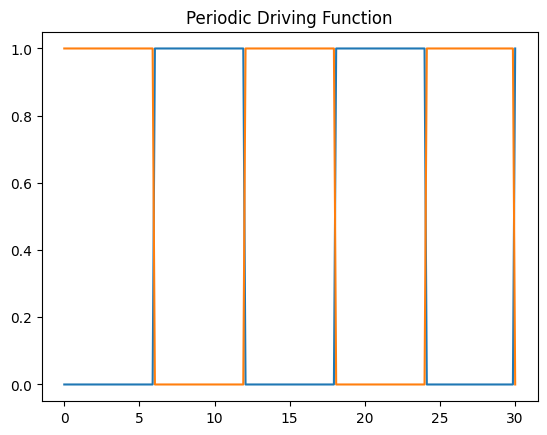

In [53]:
ts = np.linspace(0, 30, 200)
plt.plot(ts, list(map(f, ts)))
plt.plot(ts, list(map((lambda t: 1-f(t)), ts)))
plt.title('Periodic Driving Function')

In [54]:
H = I(d)
L1 =  f * TOperator.from_static(sigmaMinus) + (lambda t: 1-f(t))  * TOperator.from_static(sigmaPlus)

In [55]:
generator = GKSLGenerator(H=H, jumps=[L1])
propagator = RK4Propagator()

In [56]:
dynamics = Dynamics(propagator, generator)

## 3. Logger Setup

In [57]:
detector = ObservableDetector(sigmaZ)

In [58]:
logger = Logger([detector])
dynamics.addCallback(logger.log)

## 4. Evolution

In [59]:
initial_state = DensityMatrix(np.array([[1,0],[0,0]]))

In [60]:
dynamics.evolve(initial_state, ts=list(ts))

DensityMatrix(dim=2)

## 5. Visualisation

In [61]:
v1=logger.observable_log[detector].values()

Text(0.5, 0, '$t$')

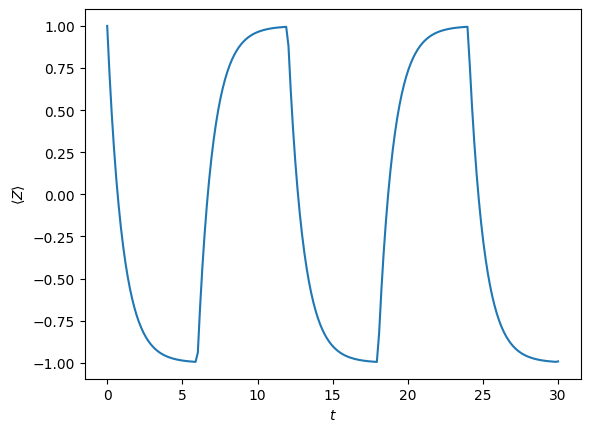

In [62]:
plt.plot(ts, logger.observable_log[detector].values())
plt.ylabel(r'$\langle Z \rangle$')
plt.xlabel('$t$')

## 6. Heisenberg Evolution

In [63]:
generator = GKSLGenerator(H=H, jumps=[L1])
propagator = RK4Propagator(ts=0.01)

In [64]:
heisenberg_dynamics = Dynamics(propagator, generator)

In [65]:
initial_state = DensityMatrix(np.array([[1,0],[0,0]]))

In [66]:
ops = [heisenberg_dynamics.evolveOperator(sigmaZ, ts=[0], t0 = t) for t in ts]

/Users/matthewmackinnon/Documents/repos/QSim/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/matthewmackinnon/Documents/repos/QSim/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


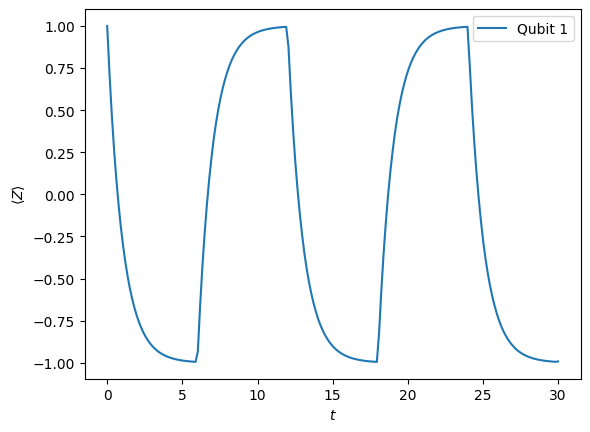

In [67]:
plt.plot(ts, [(op @ initial_state).trace() for op in ops], label='Qubit 1')
#plt.plot(ts, logger_composite.observable_log[detector_joint].values(), label = 'Joint')
plt.ylabel(r'$\langle Z \rangle$')
plt.xlabel('$t$')
plt.legend()

## 7. Superoperator Evolution

In [79]:
l_generator = LiouvillianGenerator.fromGKSL(generator)
propagator = RK4Propagator(ts=0.01)

In [80]:
dynamics = Dynamics(propagator, l_generator)

In [81]:
logger = Logger(log_state=True)
dynamics.addCallback(logger.log)

In [82]:
initial_state = Ket(vectorise(DensityMatrix(np.array([[1,0],[0,0]]))).matrix)

In [83]:
dynamics.evolve(initial_state, ts=list(ts), verbose=0)

Ket(dim=4)

In [84]:
[(unvectorise(state) @ sigmaZ).trace() for state in logger.state_log.values()][-10:]

[np.complex128(-0.9807620606941935+0j),
 np.complex128(-0.9834542285778646+0j),
 np.complex128(-0.9857696529965176+0j),
 np.complex128(-0.987761055639352+0j),
 np.complex128(-0.9894737802931732+0j),
 np.complex128(-0.9909468253101431+0j),
 np.complex128(-0.9922137315914172+0j),
 np.complex128(-0.9933033463058636+0j),
 np.complex128(-0.9942404797335579+0j),
 np.complex128(-0.9916963864381437+0j)]

In [85]:
list(v1)[-10:]

[np.float64(-0.9807620606941935),
 np.float64(-0.9834542285778646),
 np.float64(-0.9857696529965176),
 np.float64(-0.987761055639352),
 np.float64(-0.9894737802931732),
 np.float64(-0.9909468253101431),
 np.float64(-0.9922137315914172),
 np.float64(-0.9933033463058636),
 np.float64(-0.9942404797335579),
 np.float64(-0.9916963864381437)]

/Users/matthewmackinnon/Documents/repos/QSim/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/matthewmackinnon/Documents/repos/QSim/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 0, '$t$')

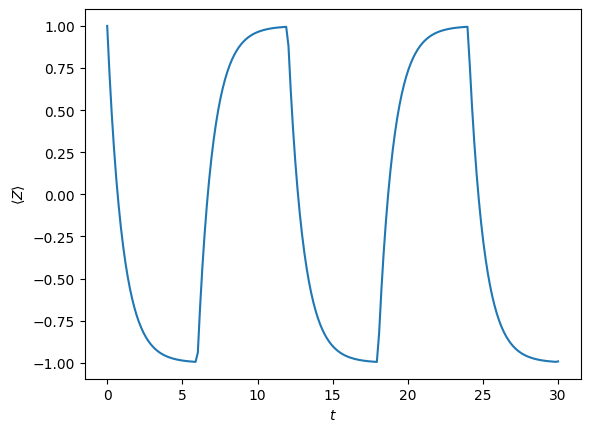

In [86]:
plt.plot(ts, [(unvectorise(state) @ sigmaZ).trace() for state in logger.state_log.values()])
plt.ylabel(r'$\langle Z \rangle$')
plt.xlabel('$t$')